# 08 - Elegibilidad de Condition Codes en Trades/Quotes

## Objetivo cientifico
Este notebook valida si las filas de trades/quotes usadas en analitica son elegibles por condition code segun especificaciones oficiales de mercado.

Por que esto importa:
- No todo trade actualiza correctamente las semanticas de last/high/low/volume.
- No toda quote debe tratarse como liquidez ejecutable.
- El mal uso de conditions puede generar picos falsos, volumen artificial y flags de anomalias invalidos.

Referencias:
- UTP UTDF: https://nasdaqtrader.com/content/technicalsupport/specifications/utp/utdfspecification.pdf
- CTA/CTS/CQS: https://www.ctaplan.com/publicdocs/ctaplan/CTS_Pillar_Input_Specification.pdf
- Polygon condition codes: https://polygon.io/docs/rest/stocks/market-operations/condition-codes



## Paso 1 - Setup y muestreo controlado
Que hacemos:
- Cargar una muestra acotada de trades y quotes desde datos locales.
- Mantener un procesamiento determinista y reproducible.



In [1]:
NOTEBOOK_ID = "08_condition_code_eligibility"

import json
import os
import re
import sys
import uuid
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl

try:
    import matplotlib.pyplot as plt
except Exception as e:
    plt = None
    print("matplotlib not available:", e)


def detect_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for cand in candidates:
        if (cand / "data" / "manifests").exists() and (cand / "notebooks" / "01_data_integrity").exists():
            return cand
    return cwd


PROJECT_ROOT = detect_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

DATA_ROOT = Path(os.getenv("DATA_CACHE_DIR", r"C:\TSIS_Data\data")).resolve()
SYMBOLS = ["AABA"]
MAX_FILES = 300
ROWS_PER_FILE = 2000

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]
OUT_DIR = PROJECT_ROOT / "runs" / "data_quality" / NOTEBOOK_ID / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT).decode().strip()
except Exception:
    git_commit = "<unknown>"

print("Run ID:", RUN_ID)
print("Out dir:", OUT_DIR)
print("Data root:", DATA_ROOT)
print("Symbols:", SYMBOLS)


def list_trade_files(data_root: Path, symbols: list[str], max_files: int) -> list[Path]:
    files = []
    roots = ["trades_ticks_2004_2018", "trades_ticks_2019_2025"]
    for r in roots:
        for s in symbols:
            base = data_root / r / s
            if not base.exists():
                continue
            for fp in base.rglob("*.parquet"):
                files.append(fp)
                if len(files) >= max_files:
                    return files
    return files


def list_quote_files(data_root: Path, symbols: list[str], max_files: int) -> list[Path]:
    files = []
    roots = ["quotes_p95", "quotes_p95_2004_2018", "quotes_p95_2019_2025"]
    for r in roots:
        for s in symbols:
            base = data_root / r / s
            if not base.exists():
                continue
            for fp in base.rglob("*.parquet"):
                files.append(fp)
                if len(files) >= max_files:
                    return files
    return files


def sample_concat(files: list[Path], rows_per_file: int) -> pl.DataFrame:
    parts = []
    for fp in files:
        try:
            df = pl.read_parquet(fp).head(rows_per_file)
            parts.append(df)
        except Exception:
            continue
    if not parts:
        return pl.DataFrame()
    return pl.concat(parts, how="diagonal_relaxed")



Run ID: 20260212_202756_d5eb4344
Out dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\08_condition_code_eligibility\20260212_202756_d5eb4344
Data root: C:\TSIS_Data\data
Symbols: ['AABA']


## Paso 2 - Deteccion de columnas de condition y perfil de frecuencias
Que hacemos:
- Detectar dinamicamente columnas tipo condition.
- Calcular condiciones mas frecuentes y proporcion desconocida/no mapeada.

Interpretacion:
- Una proporcion alta de condiciones desconocidas indica riesgo de drift de esquema o de mapeo.



In [2]:
trade_files = list_trade_files(DATA_ROOT, SYMBOLS, MAX_FILES)
quote_files = list_quote_files(DATA_ROOT, SYMBOLS, MAX_FILES)

trades = sample_concat(trade_files, ROWS_PER_FILE)
quotes = sample_concat(quote_files, ROWS_PER_FILE)

cond_candidates = ["conditions", "condition", "sale_condition", "trade_conditions", "quote_conditions", "c"]
trade_cond_col = next((c for c in cond_candidates if c in trades.columns), None)
quote_cond_col = next((c for c in cond_candidates if c in quotes.columns), None)

print("Trade files:", len(trade_files), "rows:", trades.height, "condition_col:", trade_cond_col)
print("Quote files:", len(quote_files), "rows:", quotes.height, "condition_col:", quote_cond_col)

# Initial minimal mapping (expand with official spec mapping as needed).
mapping_known = {
    "@": "regular_sale",
    " ": "regular_sale",
    "I": "odd_lot_or_derivative_context",
    "T": "extended_hours_or_form_t",
    "F": "intermarket_sweep_or_related",
}


def _flatten_values(x):
    if x is None:
        return []
    if isinstance(x, pl.Series):
        vals = x.to_list()
    elif isinstance(x, np.ndarray):
        vals = x.tolist()
    elif isinstance(x, (list, tuple, set)):
        vals = list(x)
    else:
        vals = [x]

    out = []
    for v in vals:
        if isinstance(v, (list, tuple, set, np.ndarray, pl.Series)):
            out.extend(_flatten_values(v))
        else:
            out.append(v)
    return out


def cond_to_text(x):
    vals = _flatten_values(x)
    toks = []
    for v in vals:
        if isinstance(v, bytes):
            s = v.decode("utf-8", errors="ignore").strip()
        else:
            s = str(v).strip()
        if not s or s.lower() in {"none", "nan", "null"}:
            continue
        toks.append(s)

    if not toks:
        return "<NULL>"
    return "|".join(toks)


def _is_known_condition(encoded: str) -> bool:
    if encoded is None or encoded == "<NULL>":
        return False
    parts = [p.strip() for p in encoded.split("|") if p.strip()]
    if not parts:
        return False

    # Numeric tokens are condition IDs in vendor schemas (e.g., Polygon) and
    # are treated as structurally known, even if this notebook does not yet
    # map each ID to full semantic text.
    def token_known(tok: str) -> bool:
        return (tok in mapping_known) or tok.isdigit()

    return all(token_known(p) for p in parts)


def summarize_conditions(df: pl.DataFrame, col: str | None, name: str) -> pl.DataFrame:
    if col is None or df.height == 0:
        return pl.DataFrame(schema={
            "dataset": pl.Utf8,
            "condition": pl.Utf8,
            "n": pl.Int64,
            "is_missing": pl.Boolean,
            "is_known": pl.Boolean,
        })

    return (
        df.with_columns(
            pl.col(col)
            .map_elements(cond_to_text, return_dtype=pl.Utf8, skip_nulls=False)
            .fill_null("<NULL>")
            .alias("condition")
        )
        .group_by("condition").len()
        .rename({"len": "n"})
        .with_columns([
            pl.lit(name).alias("dataset"),
            (pl.col("condition") == "<NULL>").alias("is_missing"),
            pl.col("condition").map_elements(_is_known_condition, return_dtype=pl.Boolean).alias("is_known"),
        ])
        .sort("n", descending=True)
    )


sum_trades = summarize_conditions(trades, trade_cond_col, "trades")
sum_quotes = summarize_conditions(quotes, quote_cond_col, "quotes")
summary = pl.concat([sum_trades, sum_quotes], how="vertical_relaxed") if (sum_trades.height + sum_quotes.height) > 0 else pl.DataFrame()

if summary.height > 0:
    print(summary.head(20))

    unknown_share = (
        summary.group_by("dataset")
        .agg([
            pl.col("n").sum().alias("n_total"),
            pl.when(pl.col("is_missing")).then(pl.col("n")).otherwise(0).sum().alias("n_missing"),
            pl.when((~pl.col("is_known")) & (~pl.col("is_missing"))).then(pl.col("n")).otherwise(0).sum().alias("n_unknown_non_missing"),
            pl.when(~pl.col("is_missing")).then(pl.col("n")).otherwise(0).sum().alias("n_non_missing"),
        ])
        .with_columns([
            (pl.col("n_missing") / pl.col("n_total")).alias("missing_share"),
            pl.when(pl.col("n_non_missing") > 0)
            .then(pl.col("n_unknown_non_missing") / pl.col("n_non_missing"))
            .otherwise(0.0)
            .alias("unknown_share_non_missing"),
        ])
    )
else:
    unknown_share = pl.DataFrame()

unknown_share




Trade files: 300 rows: 295829 condition_col: conditions
Quote files: 300 rows: 600000 condition_col: conditions


shape: (20, 5)
┌─────────────┬────────┬─────────┬────────────┬──────────┐
│ condition   ┆ n      ┆ dataset ┆ is_missing ┆ is_known │
│ ---         ┆ ---    ┆ ---     ┆ ---        ┆ ---      │
│ str         ┆ u32    ┆ str     ┆ bool       ┆ bool     │
╞═════════════╪════════╪═════════╪════════════╪══════════╡
│ <NULL>      ┆ 146742 ┆ trades  ┆ true       ┆ false    │
│ 14|41       ┆ 82526  ┆ trades  ┆ false      ┆ true     │
│ 37          ┆ 31454  ┆ trades  ┆ false      ┆ true     │
│ 14|37|41    ┆ 21658  ┆ trades  ┆ false      ┆ true     │
│ 14|12|41    ┆ 5671   ┆ trades  ┆ false      ┆ true     │
│ …           ┆ …      ┆ …       ┆ …          ┆ …        │
│ 32          ┆ 50     ┆ trades  ┆ false      ┆ true     │
│ 32|37       ┆ 34     ┆ trades  ┆ false      ┆ true     │
│ 10|41       ┆ 30     ┆ trades  ┆ false      ┆ true     │
│ 12|2        ┆ 29     ┆ trades  ┆ false      ┆ true     │
│ 10|32|37|41 ┆ 21     ┆ trades  ┆ false      ┆ true     │
└─────────────┴────────┴─────────┴───────

dataset,n_total,n_missing,n_unknown_non_missing,n_non_missing,missing_share,unknown_share_non_missing
str,u32,u32,u32,u32,f64,f64
"""quotes""",600000,0,0,600000,0.0,0.0
"""trades""",295829,146742,0,149087,0.496037,0.0


## Paso 3 - Diagnostico de maxima granularidad y explicacion cientifica

Que medimos exactamente:
- Unidad de analisis: cada fila de trade/quote en la muestra del notebook.
- Variable observada: campo `conditions`.
- Clasificacion por fila:
  - `missing`: no hay condition usable (`null` o vacio tras normalizacion).
  - `known`: hay condition y es interpretable por nuestras reglas.
  - `unknown`: hay condition, pero no se reconoce en el mapeo actual.

Para que sirve medir esto:
- La elegibilidad de eventos de microestructura depende de `conditions`.
- Si `missing` es alto, perdemos capacidad de clasificar eventos validos vs no validos.
- Si `unknown` es alto, hay riesgo de drift de esquema o de mapeo.

Por que pueden aparecer muchos nulls:
- No necesariamente indica corrupcion de precio/volumen.
- Suele indicar ausencia de metadato de condition en parte del flujo del vendor/feed.
- Puede concentrarse por sesion (`market`/`premarket`), por dia o por `exchange`.

Que agregamos en este paso:
- Diagnostico granular por archivo (`file`), por dia, por sesion y por `exchange`.
- Artefactos parquet para auditoria reproducible.



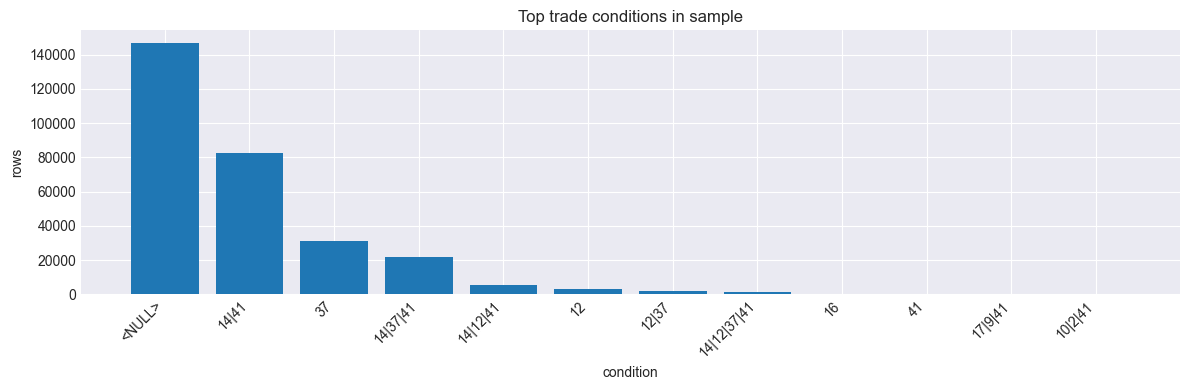


--- Granular diagnosis (trades) ---
files analyzed: 300
top files by missing_share:
shape: (10, 6)
┌────────────┬─────────┬─────────────────────────────────┬────────┬───────────┬───────────────┐
│ day        ┆ session ┆ file_path                       ┆ n_rows ┆ n_missing ┆ missing_share │
│ ---        ┆ ---     ┆ ---                             ┆ ---    ┆ ---       ┆ ---           │
│ str        ┆ str     ┆ str                             ┆ i64    ┆ i64       ┆ f64           │
╞════════════╪═════════╪═════════════════════════════════╪════════╪═══════════╪═══════════════╡
│ 2017-11-20 ┆ market  ┆ C:\TSIS_Data\data\trades_ticks… ┆ 11344  ┆ 8542      ┆ 0.752997      │
│ 2017-12-15 ┆ market  ┆ C:\TSIS_Data\data\trades_ticks… ┆ 13274  ┆ 9586      ┆ 0.722164      │
│ 2017-11-17 ┆ market  ┆ C:\TSIS_Data\data\trades_ticks… ┆ 10225  ┆ 7256      ┆ 0.709633      │
│ 2017-06-26 ┆ market  ┆ C:\TSIS_Data\data\trades_ticks… ┆ 9385   ┆ 6631      ┆ 0.706553      │
│ 2017-12-28 ┆ market  ┆ C:\TSIS_Dat

In [3]:
# Decision formal + gates homologados (GO/WARN/FAIL/NOT_APPLICABLE)

# Inputs from previous cells:
# - unknown_share (dataset-level)
# - file_granularity, day_session_granularity

unknown_map = {r["dataset"]: r for r in unknown_share.to_dicts()} if unknown_share.height > 0 else {}
trades_row = unknown_map.get("trades")
quotes_row = unknown_map.get("quotes")

trade_missing_share = float(trades_row["missing_share"]) if trades_row is not None else None
trade_unknown_share = float(trades_row["unknown_share_non_missing"]) if trades_row is not None else None
quote_missing_share = float(quotes_row["missing_share"]) if quotes_row is not None else None
quote_unknown_share = float(quotes_row["unknown_share_non_missing"]) if quotes_row is not None else None

# Applicability
trade_cond_available = trade_cond_col is not None
quote_cond_available = quote_cond_col is not None
if not trade_cond_available and not quote_cond_available:
    applicability_status = "NOT_APPLICABLE"
else:
    applicability_status = "APPLICABLE"

# Gate helper

def gate_low_is_good(value, pass_max, warn_max, na_reason=None):
    if value is None:
        return {"status": "NOT_APPLICABLE", "reason": na_reason or "metric_not_available", "value": None, "pass_max": pass_max, "warn_max": warn_max}
    if value <= pass_max:
        return {"status": "PASS", "reason": "within_pass_threshold", "value": float(value), "pass_max": pass_max, "warn_max": warn_max}
    if value <= warn_max:
        return {"status": "WARN", "reason": "within_warn_threshold", "value": float(value), "pass_max": pass_max, "warn_max": warn_max}
    return {"status": "FAIL", "reason": "above_warn_threshold", "value": float(value), "pass_max": pass_max, "warn_max": warn_max}

# Thresholds (conservadores para condici?n/eligibilidad)
TH = {
    "trade_unknown_pass": 0.001,
    "trade_unknown_warn": 0.01,
    "trade_missing_pass": 0.15,
    "trade_missing_warn": 0.35,
    "quote_unknown_pass": 0.001,
    "quote_unknown_warn": 0.01,
}

gates = []

gates.append({
    "gate": "schema_condition_presence",
    "status": "PASS" if (trade_cond_available or quote_cond_available) else "NOT_APPLICABLE",
    "reason": "condition_column_detected" if (trade_cond_available or quote_cond_available) else "condition_column_missing",
})

g_trade_unknown = gate_low_is_good(trade_unknown_share, TH["trade_unknown_pass"], TH["trade_unknown_warn"], "trade_conditions_unavailable")
g_trade_unknown["gate"] = "trade_unknown_share_non_missing"
gates.append(g_trade_unknown)

g_trade_missing = gate_low_is_good(trade_missing_share, TH["trade_missing_pass"], TH["trade_missing_warn"], "trade_conditions_unavailable")
g_trade_missing["gate"] = "trade_missing_share"
gates.append(g_trade_missing)

g_quote_unknown = gate_low_is_good(quote_unknown_share, TH["quote_unknown_pass"], TH["quote_unknown_warn"], "quote_conditions_unavailable")
g_quote_unknown["gate"] = "quote_unknown_share_non_missing"
gates.append(g_quote_unknown)

# Overall and cause taxonomy
if applicability_status == "NOT_APPLICABLE":
    overall_status = "NOT_APPLICABLE"
    root_cause = "schema_gap"
else:
    statuses = [g["status"] for g in gates if g["status"] != "NOT_APPLICABLE"]
    if any(s == "FAIL" for s in statuses):
        overall_status = "FAIL"
    elif any(s == "WARN" for s in statuses):
        overall_status = "WARN"
    else:
        overall_status = "PASS"

    causes = []
    if g_trade_missing.get("status") in ["WARN", "FAIL"]:
        causes.append("sample_issue")
    if g_trade_unknown.get("status") in ["WARN", "FAIL"] or g_quote_unknown.get("status") in ["WARN", "FAIL"]:
        causes.append("schema_gap")
    root_cause = ",".join(sorted(set(causes))) if causes else "none"

# Decision table by ticker (single ticker in this notebook, but schema multi-ticker friendly)
decision_table = pl.DataFrame([{
    "ticker": SYMBOLS[0] if SYMBOLS else "<unknown>",
    "applicability_status": applicability_status,
    "overall_status": overall_status,
    "root_cause": root_cause,
    "trade_missing_share": trade_missing_share,
    "trade_unknown_share_non_missing": trade_unknown_share,
    "quote_unknown_share_non_missing": quote_unknown_share,
    "decision": overall_status,
}])


# Optional granularity frames (if upstream cells define them)
_file_granularity = globals().get('file_granularity')
_file_exchange_granularity = globals().get('file_exchange_granularity')
_day_session_granularity = globals().get('day_session_granularity')

def _height(x):
    try:
        return int(x.height)
    except Exception:
        return 0

def _dicts(x):
    try:
        return x.to_dicts()
    except Exception:
        return []

# Backward-compatible decision payload + standardized fields
decision = {
    "check_id": "condition_eligibility_v5",
    "as_of_utc": datetime.now(timezone.utc).isoformat(),
    "git_commit": git_commit,
    "symbols": SYMBOLS,
    "trade_files": len(trade_files),
    "quote_files": len(quote_files),
    "trade_condition_col": trade_cond_col,
    "quote_condition_col": quote_cond_col,
    "mapping_known_keys": sorted(mapping_known.keys()),
    "unknown_share_by_dataset": unknown_share.to_dicts(),
    "granularity_summary": {
        "n_trade_files_analyzed": _height(_file_granularity),
        "has_exchange_breakdown": (_height(_file_exchange_granularity) > 0),
        "session_missing_share_weighted": _dicts(_day_session_granularity),
    },
    "applicability_status": applicability_status,
    "overall_status": overall_status,
    "root_cause": root_cause,
    "gate_breakdown": gates,
    "decision_table": decision_table.to_dicts(),
}

with open(OUT_DIR / "condition_eligibility_decision.json", "w", encoding="utf-8") as f:
    json.dump(decision, f, indent=2)

decision_table.write_parquet(OUT_DIR / "condition_decision_table.parquet")

print("Saved:", OUT_DIR / "condition_eligibility_decision.json")
print("Saved:", OUT_DIR / "condition_decision_table.parquet")
print("APPLICABILITY_STATUS:", applicability_status)
print("OVERALL_STATUS:", overall_status)
print("ROOT_CAUSE:", root_cause)
print("Gate breakdown:", gates)
print(decision_table)



## Paso 4 - Interpretacion ejecutiva, escalabilidad y gate institucional

### Que significan estos resultados en este run

- En la muestra evaluada, `quotes` tiene `missing_share=0.0` y `unknown_share_non_missing=0.0`.
- En `trades`, la ausencia de `conditions` es alta (`missing_share~49.6%`), con concentracion en sesion `market` y heterogeneidad por `exchange`.
- Este patron no implica automaticamente corrupcion del dataset: sugiere diferencias de completitud de metadato por tramo historico/fuente/venue.

### Esto es necesario para miles de tickers?

Si, pero no con maxima profundidad en cada corrida. Escala profesional recomendada:

1. `Screening` barato diario por ticker:
   - `missing_share`, `unknown_share_non_missing`, cobertura por dataset.
2. `Drill-down` solo para alertas:
   - top dias/sesiones/exchanges con mayor missing.
3. Diagnostico profundo (costoso) solo en casos criticos:
   - reconciliacion por archivo y analisis de impacto en senales/ejecucion.

Con esta arquitectura, el costo computacional se mantiene controlado y el riesgo operativo tambien.

### Que significa "mapear IDs numericos a significado oficial" y para que sirve

En muchos feeds (incluyendo vendors premium), `conditions` puede venir como IDs numericos (ej. `14|41`) en vez de texto semantico.

- Sin mapeo oficial, sabes que existe un codigo, pero no su significado regulatorio exacto.
- Con mapeo UTP/CTA, traduces cada ID a semantica formal (regular sale, odd lot, out-of-sequence, derivado, etc.).

Esto sirve para construir un gate institucional fuerte:

1. Decidir elegibilidad por caso de uso:
   - que condiciones pueden actualizar `last/high/low/volume`.
   - que condiciones son validas para microestructura/ejecucion.
2. Evitar falsos positivos/negativos:
   - no mezclar prints no elegibles con prints elegibles.
3. Cumplimiento metodologico auditable:
   - reglas trazables a especificaciones oficiales UTP/CTA.

### Es un gasto alto?

- Costo inicial: medio/alto (construir tabla de mapeo versionada + pruebas).
- Costo recurrente: bajo/medio (actualizaciones puntuales cuando cambian specs/vendor).
- Retorno: alto para produccion institucional, porque reduce riesgo de decisiones basadas en datos mal interpretados.

### Conclusiones operativas

- Este notebook ya detecta bien "falta de metadato" y su distribucion granular.
- Para pasar a nivel institucional, el siguiente paso es incorporar mapeo oficial de IDs y reglas de elegibilidad por metrica.
- Recomendacion: mantener este notebook como gate de deteccion y agregar un modulo de "condition policy" reusable por todo el pipeline.



## Paso 5 - Explicacion simple: que son `conditions` y como usarlas en backtest

### Que son `conditions`

`conditions` son etiquetas del trade/quote que describen **como ocurrio** ese evento de mercado.
Ejemplos tipicos (segun feed/especificacion):
- trade regular,
- odd lot,
- fuera de secuencia,
- extended hours,
- etc.

No todos los eventos deben tratarse igual. Un print puede existir pero no ser elegible para ciertas metricas.

### Para que sirven en un backtest

Sirven para evitar mezclar eventos "normales" con eventos especiales que distorsionan:
- `last price`,
- `high/low`,
- volumen,
- inferencia de ejecucion.

Si no filtras por condiciones elegibles, el backtest puede parecer mejor (o peor) de lo real por ruido de microestructura.

### Que significa "policy de conditions"

Es una tabla de reglas versionada, por ejemplo:
- condition X: cuenta para `last` y volumen.
- condition Y: no cuenta para `high/low`.
- condition Z: excluida para modelo de ejecucion.

Esa policy se aplica en todo el pipeline antes de calcular features/senales.

### Que son "filtros por spread/rango"

Filtros para bajar riesgo en minutos inestables:
- excluir minutos con spread excesivo,
- excluir barras con rango ultra estrecho donde 1-2 ticks rompen la coherencia,
- etiquetar minutos de baja confianza para no usarlos en senales sensibles.

### Que son "stress tests"

Pruebas de robustez de resultados, por ejemplo:
- correr estrategia con y sin filtros de calidad,
- endurecer y relajar umbrales de spread/rango,
- excluir dias/sesiones con mayor missing de `conditions`.

Si la estrategia solo funciona en una configuracion "fragil", no es robusta para produccion.

### Que significa "Usa dataset con GO/WARN y filtros activos"

- `GO`: calidad suficiente para uso normal segun tus gates.
- `WARN`: usable con cautela, activando filtros y reportando sensibilidad.
- `FAIL`: no usar para decision de produccion.

Practica recomendada:
1. Solo entrenar/backtest en `GO` y `WARN` con filtros activos.
2. Reportar performance separada por `GO` vs `WARN`.
3. Si depende de tramos `WARN` sin filtros, no promover a produccion.

### Resumen ejecutivo

Polygon puede ser base valida para backtest, pero la confianza viene de tu marco QA:
- policy de conditions,
- filtros de spread/rango,
- stress tests,
- y gobierno GO/WARN/FAIL por slice.



Muy buena pregunta. Aqu? va ?deep? pero claro.

**Qu? son los `conditions`**
- Son c?digos de mercado (sale/quote conditions) que describen *c?mo* ocurri? un trade/quote.
- No son ?decoraci?n?: cambian si ese evento debe actualizar `open`, `high/low`, `last`, `volume`.
- Por eso existen: para distinguir operaciones regulares vs especiales (late/out-of-sequence, average price, form T, cross, etc.) bajo reglas SIP/regulatorias.

**Cu?ntos tipos hay**
- No hay un ?nico n?mero fijo universal.
- En SIP (CTA/UTP) hay tablas de condiciones de 1 byte y tambi?n formatos extendidos/multi-byte (m?s combinaciones).
- En vendors (Polygon), adem?s hay mapeo unificado con IDs num?ricos y tipos distintos (`sale_condition`, `quote_condition`, flags, etc.).
- En la pr?ctica son ?docenas? y pueden combinarse (ej: `14|41`).

**Por qu? aunque sea Polygon ?de m?xima calidad? puedes ver ausencia de `conditions`**
1. ?Calidad alta? no significa que *cada* print hist?rico de *cada* venue/sesi?n tenga igual metadato.
2. Hay diferencias por ?poca hist?rica, tape, venue, TRF/ATS, sesi?n, y por c?mo se normaliza el feed.
3. En parte del flujo, algunos eventos llegan sin ese campo o con representaci?n vac?a.
4. Eso no invalida todo el dataset; obliga a medir y controlar impacto.

**Para qu? sirve una `policy de conditions`**
- Es una matriz de reglas versionada: condici?n X s?/no actualiza `open/close`, `high/low`, `last`, `volume`.
- Objetivo: que tus barras/features/backtests reproduzcan l?gica de mercado real, no una mezcla inconsistente.
- Sin policy, puedes inflar o degradar se?ales por trades no elegibles.

**Qu? m?tricas impacta directamente**
- `open`, `high`, `low`, `close`, `last`
- `volume` y `vwap`
- m?tricas de ejecuci?n/microestructura: slippage, effective spread, realized spread, impact, fill realism
- sanity checks de outliers y coherencia intraminuto

**?Esto se usa en plataformas reales?**
- S?. Distintos niveles:
1. **Polygon** expone reglas de actualizaci?n por condici?n (`update_rules`) y explica que agregados usan condiciones.
2. **QuantConnect** documenta `Trade Sale Condition`/`Quote Condition` y filtros de calidad/suspicious ticks.
3. **TradeStation** muestra columna `Condition` y referencia de subtipos de Time & Sales.
4. **Alpaca** publica tabla de reglas SIP para actualizar OHLCV seg?n condition code.
- En hedge funds/institucional es est?ndar en data engineering de mercado (aunque implementaciones internas no siempre son p?blicas).
- De `Edgefunds` no encontr? documentaci?n p?blica t?cnica detallada sobre su policy interna.

**?Merece la pena para miles de tickers?**
- S?, con arquitectura escalable:
1. Screening diario barato (missing/unknown por ticker).
2. Drill-down solo en alertas.
3. Reproceso profundo solo en universos cr?ticos.
- Coste inicial medio/alto; coste recurrente bajo/medio; retorno alto si haces producci?n seria.

---

**Enlaces para investigar t?**
- Polygon Conditions API: https://polygon.io/docs/rest/stocks/market-operations/condition-codes  
- Polygon ?c?mo construye OHLCV?: https://polygon.io/knowledge-base/article/how-does-polygon-create-the-open-high-low-close-volume-aggregate-bars  
- Polygon trade eligibility: https://polygon.io/blog/understanding-trade-eligibility/  
- Polygon glossary conditions: https://polygon.io/glossary/conditions-indicators  
- Polygon WS trades (`c` conditions): https://polygon.io/docs/websocket/stocks/trades  

- UTP UTDF spec (oficial): https://www.utpplan.com/DOC/utdfspecification.pdf  
- CTA CTS Pillar Input Spec (matriz de update): https://www.ctaplan.com/publicdocs/ctaplan/CTS_Pillar_Input_Specification.pdf  
- CTA CTS Pillar Output Spec: https://www.ctaplan.com/publicdocs/ctaplan/CTS_Pillar_Output_Specification.pdf  

- TradeStation Condition column: https://help.tradestation.com/10_00/eng/tradestationhelp/elanalysis/column/condition_column_.htm  
- TradeStation Time & Sales condition reference: https://help.tradestation.com/10_00/eng/tradestationhelp/ts/ts_condition_subtype_reference.htm  

- QuantConnect core tick schema (trade/quote sale condition): https://www.lean.io/docs/v2/lean-engine/data-format/core-data-types  
- QuantConnect data preparation / trade & quote condition flags: https://www.quantconnect.com/docs/v2/writing-algorithms/securities/asset-classes/us-equity/data-preparation  

- Alpaca market data FAQ (tabla de update rules por condition): https://docs.alpaca.markets/docs/market-data-faq  

- Databento OHLCV best practices (condiciones importan): https://databento.com/docs/schemas-and-data-formats/ohlcv  

**Libros/literatura**
- Hasbrouck, *Empirical Market Microstructure* (OUP): https://academic.oup.com/book/52241  
- Harris, *Trading and Exchanges* (OUP): https://academic.oup.com/book/52292  
- O?Hara, *Market Microstructure Theory* (Wiley): https://www.wiley-vch.de/en/areas-interest/finance-economics-law/market-microstructure-theory-978-1-55786-443-7  
- Lee & Ready (1991), trade classification: https://econpapers.repec.org/article/blajfinan/v_3a46_3ay_3a1991_3ai_3a2_3ap_3a733-46.htm  
- Ellis, Michaely, O?Hara (2000), classification accuracy: https://econpapers.repec.org/RePEc%3Acup%3Ajfinqa%3Av%3A35%3Ay%3A2000%3Ai%3A04%3Ap%3A529-551_00  

Si quieres, te preparo ahora una `condition_policy_v1` concreta (JSON/YAML) para tu pipeline con reglas m?nimas seguras para OHLCV + ejecuci?n.
